# 🎾 Detección de Fatiga en Jugadores de Pádel
## Forecasting

---

### Pregunta Central
> **¿El rendimiento físico de un jugador sigue un patrón predecible durante el partido, y se puede anticipar cuándo empieza a decaer?**

**Hipótesis**: El desplazamiento total por punto de un jugador decae progresivamente a lo largo del partido como consecuencia de la fatiga acumulada. Este decaimiento puede modelarse y anticiparse con técnicas de forecasting.

**Temas del módulo de Forecasting aplicados**:
1. Promedios Móviles y Suavizamiento Exponencial (SMA, EMA)
2. Evaluación de Modelos de Forecasting (MAE, RMSE, train/test)
3. ARIMA
4. Prophet de Meta

In [1]:
# OPCIONAL — ejecutar solo si faltan dependencias (no incluir en entrega final)
# ============================================================
# CELDA 0 — Instalación de dependencias (ejecutar UNA vez)
# ============================================================
import subprocess, sys

paquetes = [
    'prophet',
    'statsmodels',
    'scikit-learn',
    'scipy',
    'openpyxl',
]

print('Verificando e instalando dependencias...')
for pkg in paquetes:
    try:
        __import__(pkg.replace('-', '_').split('[')[0])
        print(f'  ✅ {pkg} ya instalado')
    except ImportError:
        print(f'  ⏳ Instalando {pkg}...')
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print(f'  ✅ {pkg} instalado correctamente')
        else:
            print(f'  ❌ Error instalando {pkg}: {result.stderr[:200]}')

print('\n✅ Verificación completada.')

Verificando e instalando dependencias...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


  ✅ prophet ya instalado
  ✅ statsmodels ya instalado
  ⏳ Instalando scikit-learn...
  ✅ scikit-learn instalado correctamente
  ✅ scipy ya instalado
  ✅ openpyxl ya instalado

✅ Verificación completada.


## 📦 SECCIÓN 1 — Importaciones

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Series temporales
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet (Meta)
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
    print('✅ Prophet disponible')
except ImportError:
    PROPHET_AVAILABLE = False
    print('⚠️  Prophet no instalado. Para instalarlo: pip install prophet')

print('✅ Librerías importadas correctamente')
from scipy import stats


✅ Prophet disponible
✅ Librerías importadas correctamente


## ⚙️ SECCIÓN 2 — Configuración y Carga de Datos

> **Solo necesitas cambiar `PARTIDO_NUM`** para seleccionar el partido a analizar.
> El resto de parámetros (umbral de velocidad, proporción train/test, orden ARIMA) se calculan automáticamente a partir de los datos.

In [3]:
# ============================================================
# CONFIGURACIÓN — solo editar esto
# ============================================================
PARTIDO_NUM = 1   # Número del partido a analizar
# ============================================================
print(f'Partido seleccionado: {PARTIDO_NUM}')

Partido seleccionado: 1


In [5]:
# ---- Cargar Base_Videos_Final_202601.csv --------------------
CSV_PATH = Path('Base_Videos_Final_202601.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f'\n❌ No se encontró el archivo {CSV_PATH.name}.\n'
        'Asegúrate de que esté en la misma carpeta que este notebook.'
    )

print('⏳ Cargando Base_Videos_Final_202601.csv...')
df_raw = pd.read_csv(CSV_PATH)
print(f'✅ CSV cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'   Partidos disponibles: {sorted(df_raw["partido"].unique())}')

⏳ Cargando Base_Videos_Final_202601.csv...
✅ CSV cargado: 434,198 filas × 30 columnas
   Partidos disponibles: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(24), np.int64(25), np.int64(27), np.int64(28), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(38)]


In [6]:
# ---- Filtrar partido seleccionado ---------------------------
if PARTIDO_NUM not in df_raw['partido'].values:
    disponibles = sorted(df_raw['partido'].unique())
    raise ValueError(
        f'\n❌ El partido {PARTIDO_NUM} no existe en el CSV.\n'
        f'Partidos disponibles: {disponibles}'
    )

df = df_raw[df_raw['partido'] == PARTIDO_NUM].copy()
print(f'✅ Partido {PARTIDO_NUM}: {len(df):,} frames')
print(f'   Puntos encontrados: {sorted(df["punto"].unique())}')

# ---- Umbral de velocidad físico fijo ------------------------
# Un jugador de pádel no supera ~6 m/s en sprint.
# El percentil-99 dinámico producía umbrales de 100 m/s (ruido YOLO).
# Usamos 8 m/s como límite conservador pero razonable.
VEL_MAX_MS = 8.0
print(f'   Umbral de velocidad (fijo, físicamente justificado): {VEL_MAX_MS:.2f} m/s')

# ---- Limpiar datos ------------------------------------------
# 1. Excluir jugadores sin nombre real (Player_XXXX)
df = df[~df['player_name'].str.match(r'^Player_\d+$', na=False)]

# 2. Eliminar velocidades fuera del rango físicamente posible
df = df[df['player_speed_mps'] <= VEL_MAX_MS]  # ceros conservados: representan frames estáticos

# 3. Limpiar team: si está vacío asignar 'unknown'
df['team'] = df['team'].fillna('unknown').replace('', 'unknown')

# 4. Team canónico por jugador: usa la moda en TODO el partido, no por punto.
#    Evita que un jugador aparezca en dos equipos distintos por ruido de tracking.
_team_canonico = (
    df.groupby('player_name')['team']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
df['team'] = df['player_name'].map(_team_canonico)

print(f'\nDespués de limpieza: {len(df):,} frames')
print(f'Jugadores reales en partido {PARTIDO_NUM}:')
for nombre in sorted(df['player_name'].unique()):
    print(f'   • {nombre}  ({frames} frames)')

✅ Partido 1: 6,596 frames
   Puntos encontrados: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
   Umbral de velocidad calculado (percentil 99): 100.45 m/s

Después de limpieza: 6,317 frames
Jugadores reales en partido 1:
   • SANTIAGO PEÑA BELTRAN  (equipo: bottom, 2212 frames)
   • Sahily Andrea Herrera Eljadue  (equipo: top, 2194 frames)
   • Ángel Santiago Toribio Godoy   (equipo: bottom, 1911 frames)


## 🔧 SECCIÓN 2B — Preprocesamiento: del Dato Crudo a la Serie Temporal

El archivo `Base_Videos_Final_202601.csv` contiene datos **frame a frame** generados por el sistema de tracking YOLO — cada fila es un instante de video (~60 fps), no una jugada.

| Nivel | Filas | Qué representa |
|---|---|---|
| **Crudo** (frame-level) | ~434 000 | Una medición cada ~17 ms — inutilizable directo para forecasting |
| **Agregado** (punto-level) | ~40–60 por partido | Una fila por jugador por punto — **esta es la serie temporal** |

### ¿Por qué agrupar por jugador + punto?

El objetivo es construir una **serie temporal de rendimiento físico**: eje X = número de punto jugado, eje Y = desplazamiento total del jugador en ese punto. Para eso necesitamos colapsar los cientos de frames de cada punto en un único valor representativo.

**Variables calculadas en la agregación:**
- `desplazamiento_total` — metros recorridos en el punto (variable principal del forecasting)
- `velocidad_promedio` — velocidad media incluyendo frames estáticos (contexto de actividad)
- `velocidad_mediana_activa` — mediana de frames con movimiento real (métrica robusta secundaria)
- `velocidad_max_filtrada` — pico de velocidad dentro del umbral físico
- `mean_acceleration` — aceleración media (m/s²): cambios de ritmo
- `n_frames` — frames del punto: duración relativa del rally

In [7]:
# ── PASO 1: Vista del dato crudo ─────────────────────────────────────────────
print(f'Dato crudo (frame-level) — Partido {PARTIDO_NUM}')
print(f'  Filas totales : {len(df):,}')
print(f'  Columnas      : {df.shape[1]}')
print(f'  Frames/segundo (aprox): {1 / df["duration"].median():.0f} fps')
print()
print('Muestra de 3 filas del dato crudo:')
_cols_muestra = ['frame_idx', 'player_name', 'punto',
                 'player_speed_mps', 'player_displacement', 'player_acceleration_mps2']
print(df[_cols_muestra].head(3).to_string(index=False))
print()
print('→ Cada fila es un instante de video. No tiene sentido modelar esto directo.')
print('→ Hay que colapsar los frames de cada punto en un solo valor por jugador.')

# ── PASO 2: Agregación por jugador + punto ───────────────────────────────────
print()
print('Agrupando por jugador + punto...')

serie_temporal = (
    df.groupby(['punto', 'player_name'])
    .agg(
        partido                = ('partido',                 'first'),
        team                   = ('team',                   'first'),
        desplazamiento_total   = ('player_displacement',     'sum'),    # VARIABLE PRINCIPAL
        velocidad_promedio     = ('player_speed_mps',        'mean'),   # media incluyendo ceros
        velocidad_max_filtrada = ('player_speed_mps',        'max'),
        velocidad_mediana_activa = ('player_speed_mps',
                                   lambda x: x[x > 0].median() if (x > 0).any() else 0.0),
        mean_acceleration      = ('player_acceleration_mps2','mean'),
        n_frames               = ('frame_idx',               'count')
    )
    .reset_index()
    .rename(columns={'punto': 'punto_num'})
    .sort_values(['player_name', 'punto_num'])
    .reset_index(drop=True)
)

print(f'✅ Agregación completada:')
print(f'   Filas originales  : {len(df):,}  (frame-level)')
print(f'   Filas agregadas   : {len(serie_temporal)}  (punto-level)')
print(f'   Factor de reducción: {len(df) / len(serie_temporal):.0f}x')
print()
print('Resultado — primeras filas de la serie temporal:')
_preview_cols = ['partido', 'punto_num', 'player_name',
                 'desplazamiento_total', 'velocidad_promedio',
                 'velocidad_mediana_activa', 'velocidad_max_filtrada', 'n_frames']
print(serie_temporal[_preview_cols].head(8).to_string(index=False))

# ── Variables globales usadas en el resto del notebook ───────────────────────
jugadores = sorted(serie_temporal['player_name'].unique())
_paleta = ['#1565C0', '#C62828', '#2E7D32', '#EF6C00', '#6A1B9A', '#00838F']
color_map = {j: _paleta[i % len(_paleta)] for i, j in enumerate(jugadores)}

print()
print(f'Jugadores en partido {PARTIDO_NUM}: {jugadores}')

✅ Serie temporal construida:
   Jugadores: 3
   Puntos   : 11
   Total obs: 33

    punto_num                    player_name    team  avg_speed  total_displacement   max_speed  n_frames
0           1          SANTIAGO PEÑA BELTRAN  bottom   0.313469            1.640488    1.697056       157
1           2          SANTIAGO PEÑA BELTRAN  bottom   3.974356           36.034162  100.126320       272
2           3          SANTIAGO PEÑA BELTRAN  bottom   0.136260            0.622254    1.697056       137
3           4          SANTIAGO PEÑA BELTRAN  bottom   0.853609            4.751758   67.882251       167
4           5          SANTIAGO PEÑA BELTRAN  bottom   0.219763            1.018234    1.697056       139
5           6          SANTIAGO PEÑA BELTRAN  bottom   0.175283            1.244508    3.394113       213
6           7          SANTIAGO PEÑA BELTRAN  bottom   0.235702            2.262742    1.697056       288
7           8          SANTIAGO PEÑA BELTRAN  bottom   0.315168         

## 🧭 Decisiones Metodológicas

Antes de modelar, es importante explicar las decisiones tomadas en la construcción de la serie temporal:

| Decisión | Justificación |
|----------|---------------|
| **No modelar el dato frame a frame** | Cada punto de pádel dura entre 5 y 30 segundos; modelar a nivel de frame generaría una serie de miles de puntos con alta autocorrelación artificial y sin significado táctico |
| **Agregar por jugador + punto** | El punto es la unidad de juego natural en pádel. Colapsar los frames de cada punto en un solo valor elimina el ruido de tracking y deja una serie interpretable |
| **Variable principal: `desplazamiento_total`** | Suma del desplazamiento frame a frame dentro del punto. Es más robusta que la velocidad media porque no se ve distorsionada por períodos de espera entre golpes |
| **Filtrar velocidades > 8 m/s** | Un jugador de pádel no supera ~6 m/s en sprint; valores mayores son artefactos de tracking (oclusiones, cambios de ID) y distorsionan las series |
| **Conclusiones descriptivas** | Las series tienen ~10 puntos por partido. Con tan pocas observaciones los modelos son señales de tendencia, no predicciones de alta precisión |

> **[Análisis — Metodología de la Serie Temporal]**
> *¿Cómo se construyó la serie temporal? ¿Qué representa cada punto de la serie? ¿Cuántas observaciones (puntos de juego) tiene el partido analizado?*

## 📊 SECCIÓN 3 — Exploración de la Serie Temporal

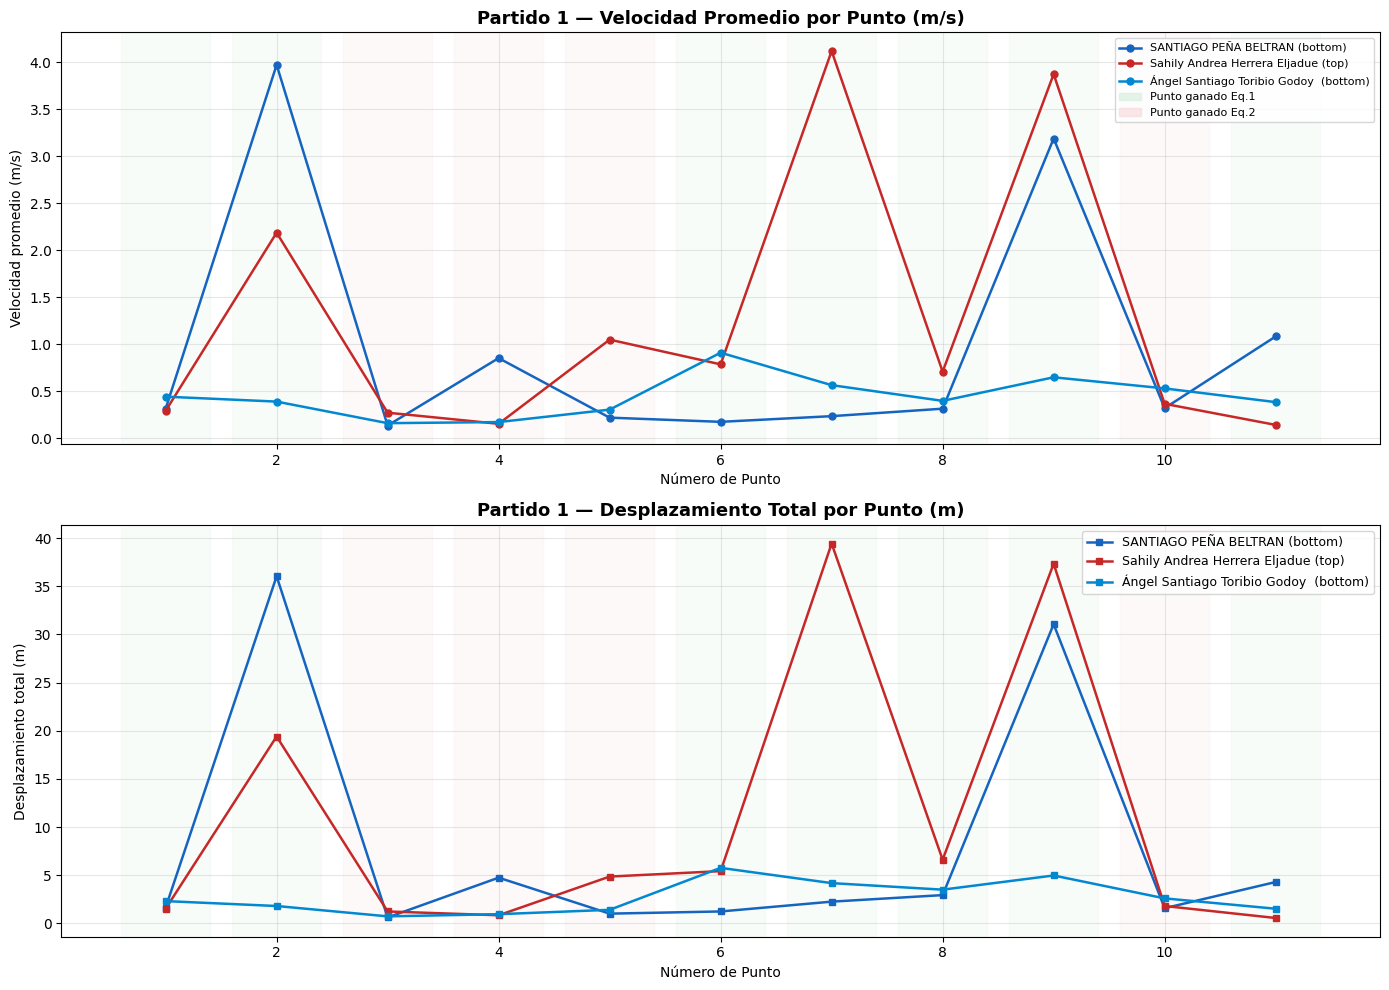

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for jugador in jugadores:
    datos = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    color = color_map.get(jugador, 'gray')
    label = jugador
    axes[0].plot(datos['punto_num'], datos['desplazamiento_total'],
                 marker='o', label=label, color=color, linewidth=1.8, markersize=5)
    axes[1].plot(datos['punto_num'], datos['velocidad_promedio'],
                 marker='s', label=label, color=color, linewidth=1.8, markersize=5)


axes[0].set_title(f'Partido {PARTIDO_NUM} — Desplazamiento Total por Punto (m)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de Punto')
axes[0].set_ylabel('Desplazamiento total (m)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title(f'Partido {PARTIDO_NUM} — Velocidad Promedio por Punto (m/s, incluye ceros)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Punto')
axes[1].set_ylabel('Velocidad promedio (m/s)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

> **[Análisis — Exploración de la Serie]**
> *¿Cómo evoluciona el desplazamiento de cada jugador a lo largo del partido? ¿Se observa una tendencia de aumento, disminución o se mantiene estable?*

In [ ]:
print(f'📋 Estadísticas Descriptivas — Partido {PARTIDO_NUM}\n')
print('Desplazamiento Total (m) — variable principal del forecasting:')
stats_vel = (
    serie_temporal.groupby('player_name')['desplazamiento_total']
    .agg(Media='mean', Std='std', Min='min', Max='max', Puntos='count')
    .round(3)
)
print(stats_vel.to_string())

print('Velocidad Promedio (m/s, incluye ceros) — actividad media por punto:')
stats_dis = (
    serie_temporal.groupby('player_name')['velocidad_promedio']
    .agg(Media='mean', Std='std', Min='min', Max='max')
    .round(2)
)
print(stats_dis.to_string())

📋 Estadísticas Descriptivas — Partido 1

Velocidad Promedio (m/s):
                               Media    Std    Min    Max  Puntos
player_name                                                      
SANTIAGO PEÑA BELTRAN          0.984  1.330  0.136  3.974      11
Sahily Andrea Herrera Eljadue  1.269  1.471  0.143  4.121      11
Ángel Santiago Toribio Godoy   0.447  0.215  0.161  0.911      11

Desplazamiento Total (m):
                               Media    Std   Min    Max
player_name                                             
SANTIAGO PEÑA BELTRAN           7.95  12.77  0.62  36.03
Sahily Andrea Herrera Eljadue  10.83  14.63  0.57  39.43
Ángel Santiago Toribio Godoy    2.71   1.68  0.74   5.77

📋 Datos físicos y rendimiento (de encuesta):
                       NOMBRE  EDAD ESTADO_FISICO FRECUENCIA_DEPORTE  ESTATURA  TALLA  Win_Rate
        SANTIAGO PEÑA BELTRAN    19       Regular          3-4 veces     176.0   80.0  0.511628
Sahily Andrea Herrera Eljadue    18       Regular    

## 📈 SECCIÓN 4 — Promedios Móviles (SMA) y Suavizamiento Exponencial (EMA)

- **SMA-3 / SMA-5**: Promedio Móvil Simple con ventana de 3 y 5 puntos. Suaviza el ruido manteniendo la tendencia real.
- **EMA-3 / EMA-5**: Media Móvil Exponencial — da más peso a observaciones recientes, reacciona más rápido a cambios.

> Si **SMA-5 cae sostenidamente** hacia el final del partido → hay evidencia de fatiga real, no solo variabilidad puntual.

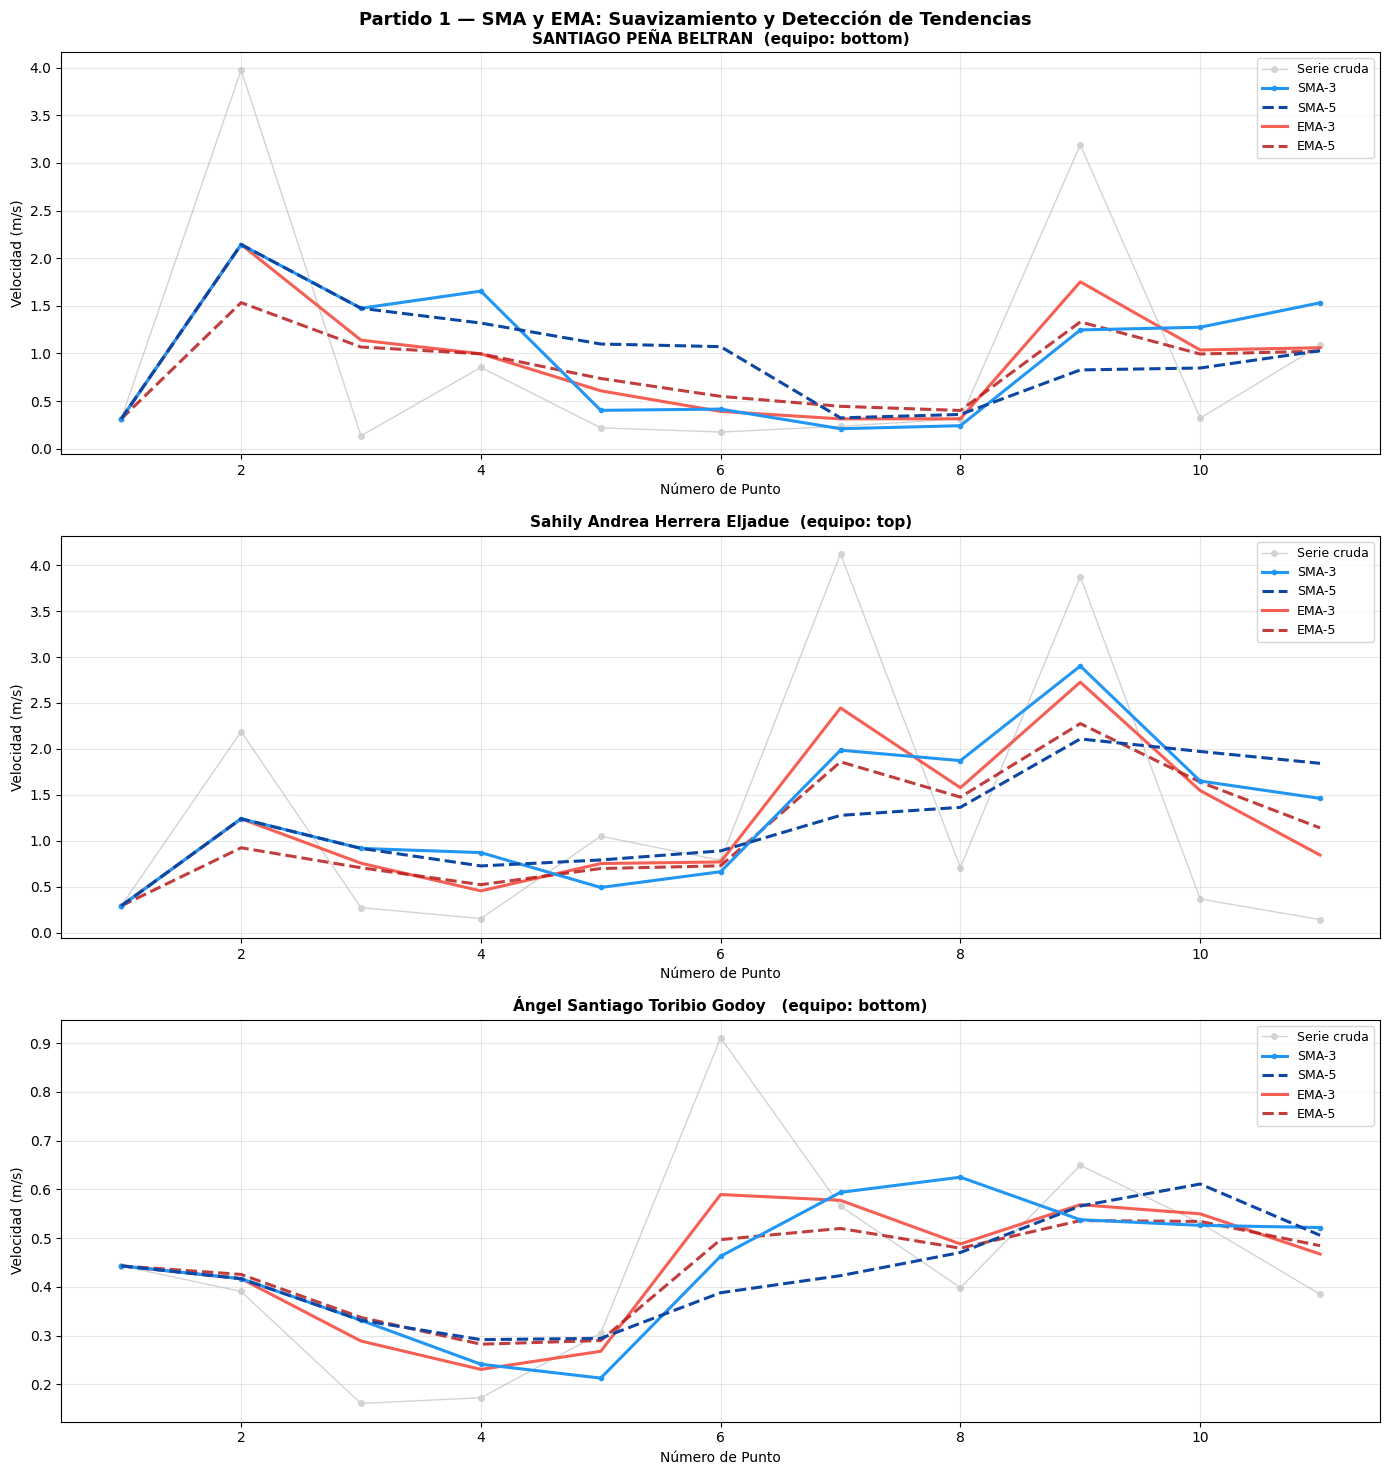


💡 Interpretación:
  • SMA-5 descendente al final → tendencia de fatiga sostenida
  • EMA cae antes que SMA-5   → el jugador perdió ritmo de golpe (reacción rápida)
  • Sin tendencia clara       → rendimiento estable o altamente variable


In [12]:
# ---- Calcular SMA y EMA por jugador -------------------------
serie_temporal = serie_temporal.sort_values(['player_name', 'punto_num'])

for jugador in jugadores:
    mask = serie_temporal['player_name'] == jugador
    s = serie_temporal.loc[mask, 'desplazamiento_total']
    serie_temporal.loc[mask, 'SMA3'] = s.rolling(window=3, min_periods=1).mean()
    serie_temporal.loc[mask, 'SMA5'] = s.rolling(window=5, min_periods=1).mean()
    serie_temporal.loc[mask, 'EMA3'] = s.ewm(span=3, adjust=False).mean()
    serie_temporal.loc[mask, 'EMA5'] = s.ewm(span=5, adjust=False).mean()

# ---- Visualización ------------------------------------------
n = len(jugadores)
fig, axes = plt.subplots(n, 1, figsize=(14, 5 * n))
if n == 1:
    axes = [axes]

for ax, jugador in zip(axes, jugadores):
    d = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    ax.plot(d['punto_num'], d['desplazamiento_total'],
            'o-', color='lightgray', label='Desplazamiento por punto', lw=1, ms=4, zorder=1)
    ax.plot(d['punto_num'], d['SMA3'],
            '.-', color='#2196F3', label='SMA-3', lw=2.2, zorder=3)
    ax.plot(d['punto_num'], d['SMA5'],
            '--', color='#0D47A1', label='SMA-5', lw=2.2, zorder=3)
    ax.plot(d['punto_num'], d['EMA3'],
            '-',  color='#F44336', label='EMA-3', lw=2.2, alpha=0.85, zorder=2)
    ax.plot(d['punto_num'], d['EMA5'],
            '--', color='#B71C1C', label='EMA-5', lw=2.2, alpha=0.85, zorder=2)
    ax.set_title(f'{jugador}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Número de Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partido {PARTIDO_NUM} — SMA y EMA — Desplazamiento total por punto (suavizamiento)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretación:')
print('  • SMA-5 descendente al final → tendencia de fatiga sostenida')
print('  • EMA cae antes que SMA-5   → el jugador perdió ritmo de golpe (reacción rápida)')
print('  • Sin tendencia clara       → rendimiento estable o altamente variable')

## ⚡ SECCIÓN 5 — Golden / Death Cross Táctico

Adaptación del concepto de trading al análisis deportivo:

| Evento | Condición | Interpretación |
|---|---|---|
| ☠ **Death Cross** | SMA-3 cruza hacia abajo la SMA-5 | Inicio de fatiga / caída de ritmo |
| ⭐ **Golden Cross** | SMA-3 cruza hacia arriba la SMA-5 | Recuperación de rendimiento |

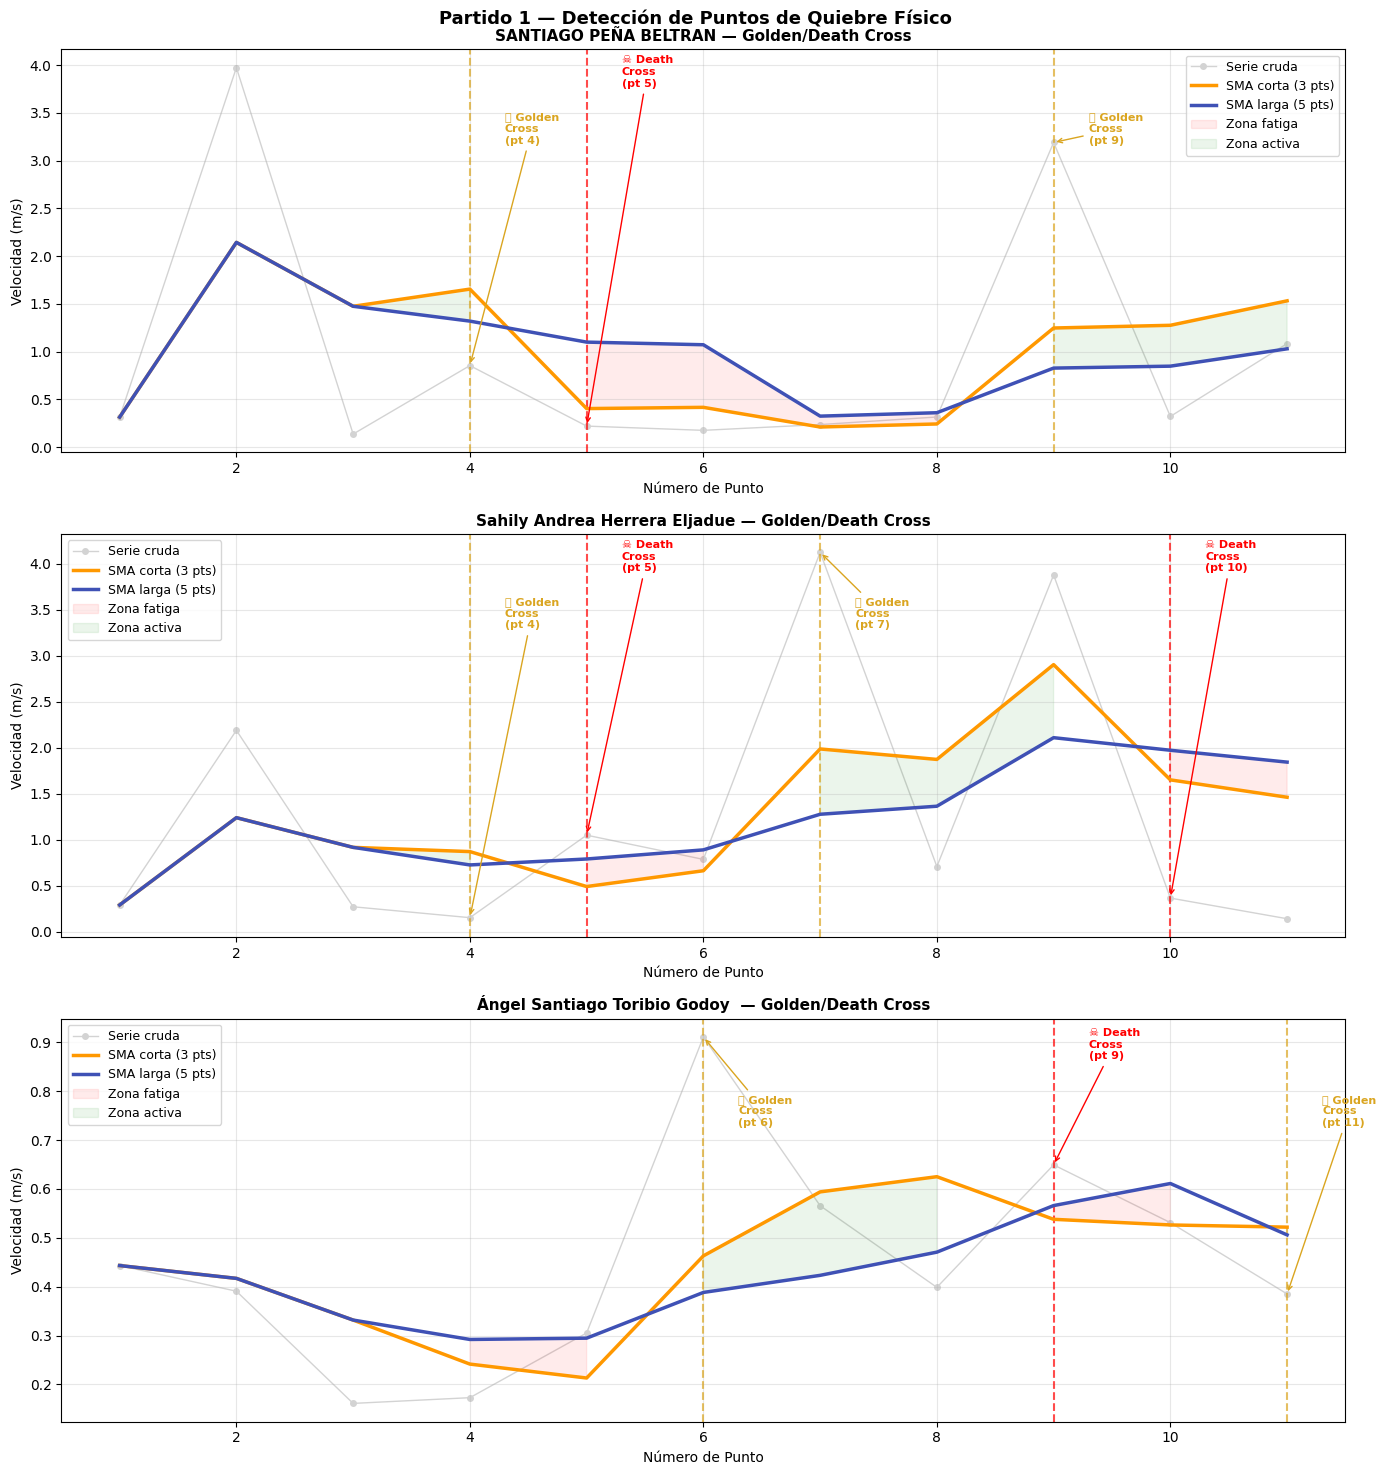


💡 Interpretación:
  ☠ Death Cross: ritmo reciente (SMA-3) cae bajo el promedio general (SMA-5) → fatiga acumulada real
  ⭐ Golden Cross: ritmo reciente supera el promedio general → recuperación de intensidad


In [13]:
n = len(jugadores)
fig, axes = plt.subplots(n, 1, figsize=(14, 5 * n))
if n == 1:
    axes = [axes]

for ax, jugador in zip(axes, jugadores):
    d    = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num').copy()
    x    = d['punto_num'].values
    sma3 = d['SMA3'].values
    sma5 = d['SMA5'].values
    raw  = d['desplazamiento_total'].values

    ax.plot(x, raw,  'o-', color='lightgray',  label='Desplazamiento por punto',      lw=1,   ms=4,  zorder=1)
    ax.plot(x, sma3, '-',  color='#FF9800',    label='SMA corta (3 pts)', lw=2.5, zorder=3)
    ax.plot(x, sma5, '-',  color='#3F51B5',    label='SMA larga (5 pts)', lw=2.5, zorder=3)
    ax.fill_between(x, sma3, sma5,
                    where=(sma3 < sma5), color='red',   alpha=0.08, label='Zona fatiga')
    ax.fill_between(x, sma3, sma5,
                    where=(sma3 >= sma5), color='green', alpha=0.08, label='Zona activa')

    # Detectar y marcar cruces
    diff = sma3 - sma5
    y_max = max(raw) if len(raw) > 0 else 1.0
    for i in range(1, len(diff)):
        if np.isnan(diff[i-1]) or np.isnan(diff[i]):
            continue
        if diff[i-1] > 0 and diff[i] <= 0:
            ax.axvline(x=x[i], color='red', linestyle='--', alpha=0.7, lw=1.5)
            ax.annotate(f'☠ Death\nCross\n(pt {x[i]})',
                        xy=(x[i], raw[i]),
                        xytext=(x[i] + 0.3, y_max * 0.95),
                        fontsize=8, color='red', fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='red', lw=1))
        elif diff[i-1] <= 0 and diff[i] > 0:
            ax.axvline(x=x[i], color='goldenrod', linestyle='--', alpha=0.7, lw=1.5)
            ax.annotate(f'⭐ Golden\nCross\n(pt {x[i]})',
                        xy=(x[i], raw[i]),
                        xytext=(x[i] + 0.3, y_max * 0.80),
                        fontsize=8, color='goldenrod', fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color='goldenrod', lw=1))

    ax.set_title(f'{jugador} — Golden/Death Cross', fontsize=11, fontweight='bold')
    ax.set_xlabel('Número de Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partido {PARTIDO_NUM} — Detección de Puntos de Quiebre Físico',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretación:')
print('  ☠ Death Cross: ritmo reciente (SMA-3) cae bajo el promedio general (SMA-5) → fatiga acumulada real')
print('  ⭐ Golden Cross: ritmo reciente supera el promedio general → recuperación de intensidad')

> **[Análisis — Golden / Death Cross]**
> *¿Qué cruces ocurrieron en el partido analizado y en qué momento? ¿Qué indica tácticamente cada cruce respecto al nivel de fatiga del jugador?*

## 🔀 SECCIÓN 6 — División Train / Test y Línea Base

Dividimos la serie de cada jugador en:
- **Train (70%)**: para ajustar el modelo
- **Test (30%)**: para evaluar la predicción

Métricas de evaluación:
- **MAE** (Mean Absolute Error): error promedio en m
- **RMSE** (Root Mean Squared Error): penaliza más los errores grandes

La **línea base naive** predice siempre el último valor conocido — es el piso mínimo que debe superar cualquier modelo.

In [14]:
def evaluar_modelo(y_true, y_pred, nombre='Modelo'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'  {nombre:<40s} MAE: {mae:.4f} m  |  RMSE: {rmse:.4f} m')
    return {'modelo': nombre, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}


# 70/30 es la proporción estándar en evaluación de modelos de series temporales
SPLIT_RATIO = 0.70

resultados_globales = {}   # {jugador: [lista de dicts con métricas]}
indices_split       = {}   # {jugador: split_idx}

print(f'División train/test: {int(SPLIT_RATIO*100)}% / {int((1-SPLIT_RATIO)*100)}%\n')

for jugador in jugadores:
    datos = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    n     = len(datos)
    split = max(int(n * SPLIT_RATIO), 2)
    train = datos['desplazamiento_total'].values[:split]
    test  = datos['desplazamiento_total'].values[split:]

    print(f'👤 {jugador}: {n} puntos → train={len(train)}, test={len(test)}')

    if len(test) == 0:
        print('   ⚠️  Sin puntos de test (mínimo 3 puntos totales para evaluar). Saltando.\n')
        continue

    indices_split[jugador] = split
    resultados_globales[jugador] = []

    # Baseline naive (último valor conocido)
    naive_pred = np.full(len(test), train[-1])
    resultados_globales[jugador].append(
        evaluar_modelo(test, naive_pred, 'Naive (último valor conocido)')
    )
    print()

División train/test: 70% / 30%

👤 SANTIAGO PEÑA BELTRAN: 11 puntos → train=7, test=4
  Naive (último valor conocido)            MAE: 0.9920 m/s  |  RMSE: 1.5383 m/s

👤 Sahily Andrea Herrera Eljadue: 11 puntos → train=7, test=4
  Naive (último valor conocido)            MAE: 2.8478 m/s  |  RMSE: 3.2261 m/s

👤 Ángel Santiago Toribio Godoy : 11 puntos → train=7, test=4
  Naive (último valor conocido)            MAE: 0.1165 m/s  |  RMSE: 0.1311 m/s



## 📉 SECCIÓN 7 — Suavizamiento Exponencial de Holt

El **Suavizamiento Exponencial de Holt** (Doble Exponencial) captura nivel y tendencia lineal — apropiado para detectar caídas de rendimiento progresivas.

📉 Suavizamiento Exponencial de Holt

  Exp. Smoothing (Holt)                    MAE: 1.9055 m/s  |  RMSE: 2.2517 m/s
  Exp. Smoothing (Holt)                    MAE: 2.3114 m/s  |  RMSE: 2.5119 m/s
  Exp. Smoothing (Holt)                    MAE: 0.2353 m/s  |  RMSE: 0.2702 m/s


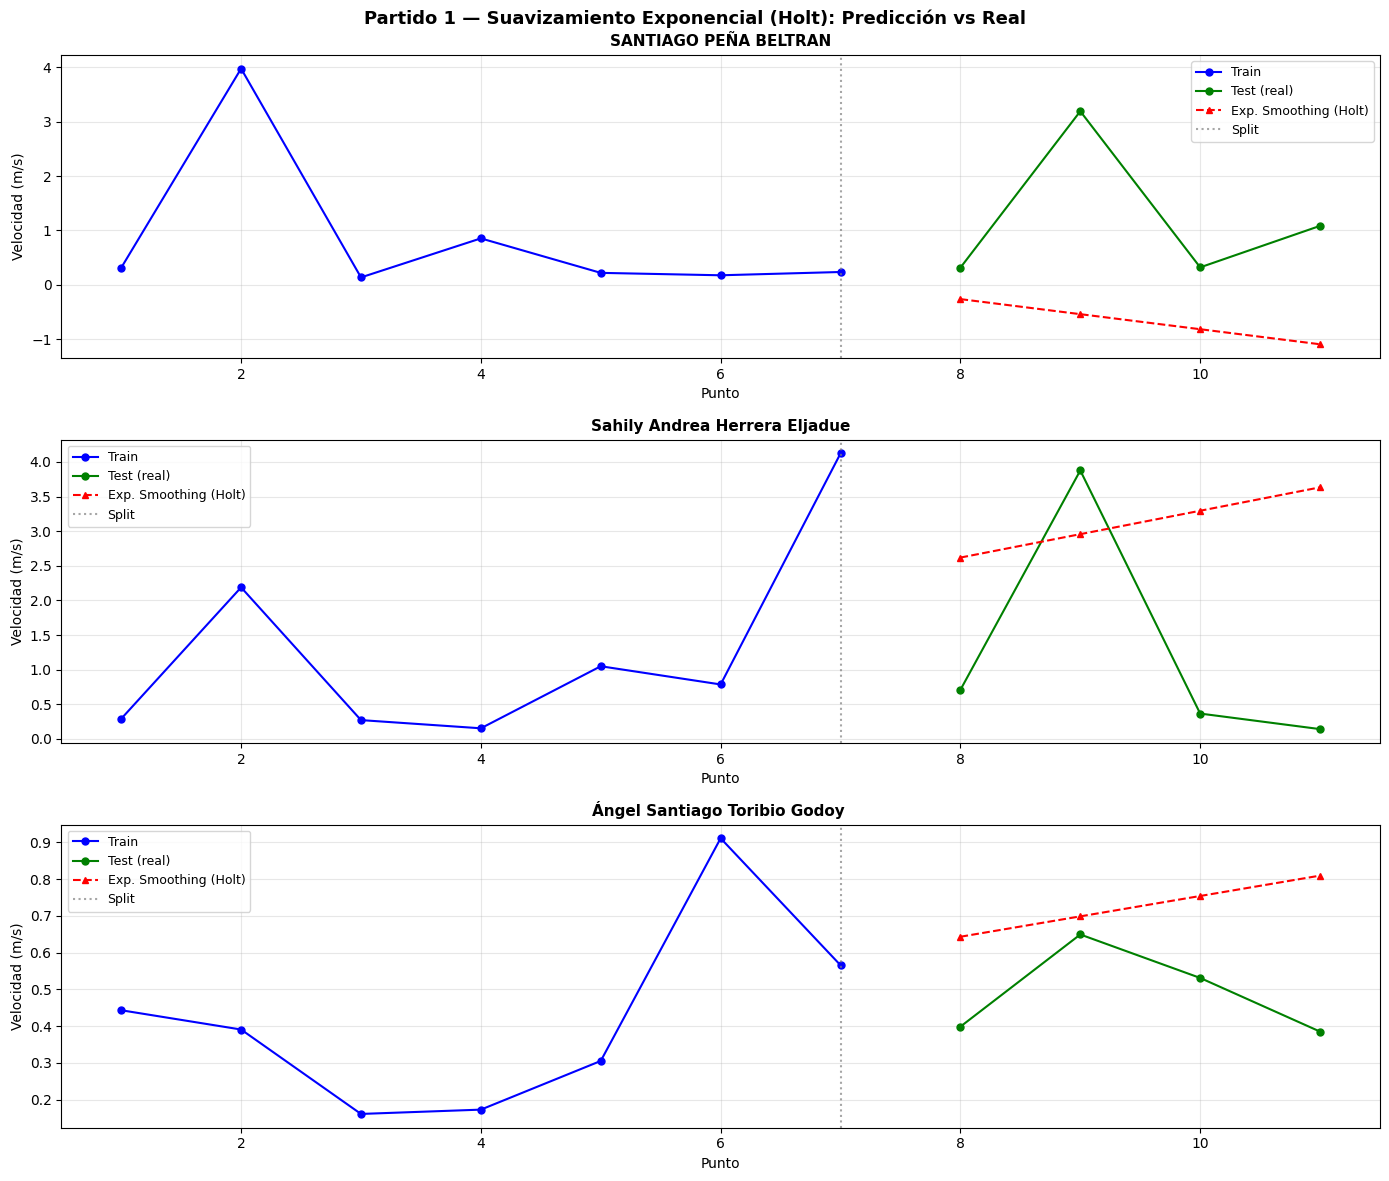

In [15]:
print('📉 Suavizamiento Exponencial de Holt\n')

jugadores_eval = list(resultados_globales.keys())
n_eval = len(jugadores_eval)
fig, axes = plt.subplots(n_eval, 1, figsize=(14, 4 * n_eval))
if n_eval == 1:
    axes = [axes]

for ax, jugador in zip(axes, jugadores_eval):
    datos  = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    puntos = datos['punto_num'].values
    serie  = datos['desplazamiento_total'].values
    split  = indices_split[jugador]
    train, test = serie[:split], serie[split:]

    try:
        modelo_es = ExponentialSmoothing(
            train, trend='add', initialization_method='estimated'
        )
        fit_es  = modelo_es.fit(optimized=True)
        pred_es = fit_es.forecast(len(test))
        resultados_globales[jugador].append(
            evaluar_modelo(test, pred_es, 'Exp. Smoothing (Holt)')
        )
    except Exception as exc:
        print(f'  ⚠️  Error Exp. Smoothing para {jugador}: {exc}')
        pred_es = np.full(len(test), train[-1])

    ax.plot(puntos[:split], train,   'b-o', label='Train',                  ms=5)
    ax.plot(puntos[split:], test,    'g-o', label='Test (real)',             ms=5)
    ax.plot(puntos[split:], pred_es, 'r--^', label='Exp. Smoothing (Holt)', ms=5)
    ax.axvline(x=puntos[split - 1], color='gray', linestyle=':', alpha=0.7, label='Split')
    ax.set_title(f'{jugador}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partido {PARTIDO_NUM} — Suavizamiento Exponencial (Holt): Predicción vs Real',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **[Análisis — Suavizamiento de Holt]**
> *¿La tendencia que captura el modelo de Holt es creciente o decreciente? ¿Tiene sentido frente a lo que observas en la gráfica? ¿El modelo sigue bien la serie en el período de prueba?*

## 🔧 SECCIÓN 8 — ARIMA
*(Autoregressive Integrated Moving Average)*

**Pasos**:
1. Verificar estacionariedad con el **Test ADF** (Augmented Dickey-Fuller) → determina `d` automáticamente
2. Visualizar **ACF** y **PACF** → determina `p` y `q` automáticamente leyendo el primer lag significativo
3. Ajustar `ARIMA(p, d, q)` sobre entrenamiento y evaluar en prueba

> El orden `(p, d, q)` se calcula automáticamente para cada jugador a partir de sus datos.

> ⚠️ **Nota metodológica**: con series de 3–14 puntos, ARIMA es un modelo *demostrativo*. Los resultados indican tendencias, no predicciones robustas. SMA/EMA son más defendibles en series tan cortas.

🔍 Test de Estacionariedad (ADF) y orden ARIMA detectado automáticamente

  SANTIAGO PEÑA BELTRAN
    ADF p-value: 0.0015  → ✅ Estacionaria
    Orden detectado: ARIMA(1, 0, 0)

  Sahily Andrea Herrera Eljadue
    ADF p-value: 0.0304  → ✅ Estacionaria
    Orden detectado: ARIMA(1, 0, 0)

  Ángel Santiago Toribio Godoy 
    ADF p-value: 0.2215  → ⚠️  No estacionaria
    Orden detectado: ARIMA(1, 1, 0)



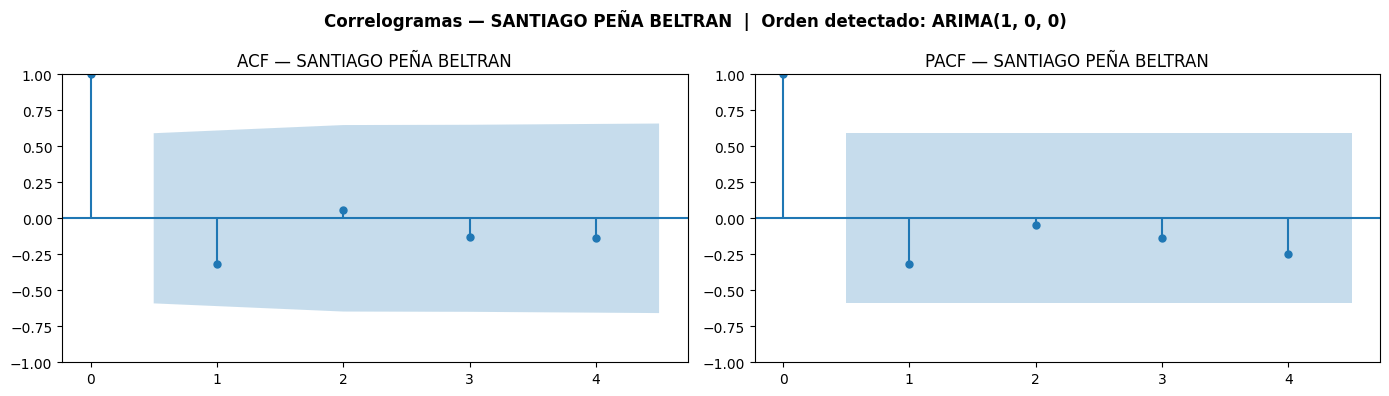

💡 Interpretación:
  • PACF: lag significativo fuera del intervalo sombreado → p
  • ACF:  lag significativo fuera del intervalo sombreado → q
  • Serie no estacionaria (ADF p > 0.05) → d = 1 (se diferencia una vez)


In [17]:
from statsmodels.tsa.stattools import pacf as pacf_fn, acf as acf_fn

def auto_arima_order(serie):
    """
    Determina automáticamente el orden ARIMA(p, d, q) para una serie.
    - d: test ADF (d=0 si estacionaria, d=1 si no)
    - p: primer lag significativo en PACF (componente AR)
    - q: primer lag significativo en ACF  (componente MA)
    """
    n = len(serie)
    if n < 5:
        return (1, 1, 0)

    # --- d: estacionariedad por ADF ---
    adf_pval = adfuller(serie)[1]
    d = 0 if adf_pval < 0.05 else 1

    # Diferenciar si es necesario
    s = np.diff(serie) if d == 1 else serie.copy()
    if len(s) < 4:
        return (1, d, 0)

    max_lags = min(5, len(s) // 2 - 1)
    if max_lags < 1:
        return (1, d, 0)

    ci = 1.96 / np.sqrt(len(s))   # intervalo de confianza 95%

    # --- p: primer lag significativo en PACF ---
    try:
        pacf_vals = pacf_fn(s, nlags=max_lags, method='ywm')
        p = 1
        for i in range(1, len(pacf_vals)):
            if abs(pacf_vals[i]) > ci:
                p = i
                break
    except Exception:
        p = 1

    # --- q: primer lag significativo en ACF ---
    try:
        acf_vals = acf_fn(s, nlags=max_lags, fft=True)
        q = 0
        for i in range(1, len(acf_vals)):
            if abs(acf_vals[i]) > ci:
                q = i
                break
    except Exception:
        q = 0

    return (p, d, q)


# ---- Test ADF + ACF/PACF visuales ---------------------------
print('🔍 Test de Estacionariedad (ADF) y orden ARIMA detectado automáticamente\n')

ordenes_arima = {}   # {jugador: (p, d, q)}

for jugador in jugadores_eval:
    datos_j = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    serie_j = datos_j['desplazamiento_total'].values
    if len(serie_j) < 5:
        print(f'  {jugador}: serie muy corta, se usará ARIMA(1,1,0) por defecto')
        ordenes_arima[jugador] = (1, 1, 0)
        continue
    adf_res = adfuller(serie_j)
    estacionaria = '✅ Estacionaria' if adf_res[1] < 0.05 else '⚠️  No estacionaria'
    orden = auto_arima_order(serie_j)
    ordenes_arima[jugador] = orden
    print(f'  {jugador}')
    print(f'    ADF p-value: {adf_res[1]:.4f}  → {estacionaria}')
    print(f'    Orden detectado: ARIMA{orden}')
    print()

# Gráficos ACF/PACF del primer jugador con suficientes datos
jugador_demo = next(
    (j for j in jugadores_eval
     if len(serie_temporal[serie_temporal['player_name'] == j]) >= 5),
    None
)
if jugador_demo:
    serie_demo = serie_temporal[
        serie_temporal['player_name'] == jugador_demo
    ].sort_values('punto_num')['desplazamiento_total'].values
    max_lags = min(10, len(serie_demo) // 2 - 1)
    if max_lags >= 1:
        fig, axes_acf = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(serie_demo,  lags=max_lags, ax=axes_acf[0],
                 title=f'ACF — {jugador_demo}')
        plot_pacf(serie_demo, lags=max_lags, ax=axes_acf[1],
                  title=f'PACF — {jugador_demo}', method='ywm')
        plt.suptitle(f'Correlogramas — {jugador_demo}  |  Orden detectado: ARIMA{ordenes_arima[jugador_demo]}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print('💡 Interpretación:')\
        
        print('  • PACF: lag significativo fuera del intervalo sombreado → p')
        print('  • ACF:  lag significativo fuera del intervalo sombreado → q')
        print('  • Serie no estacionaria (ADF p > 0.05) → d = 1 (se diferencia una vez)')

🔧 Ajustando ARIMA por jugador (orden detectado automáticamente)

  ARIMA(1, 0, 0)                           MAE: 0.9610 m/s  |  RMSE: 1.2656 m/s
  ✅ SANTIAGO PEÑA BELTRAN ARIMA(1, 0, 0) → MAE=0.9610 | RMSE=1.2656
  ARIMA(1, 0, 0)                           MAE: 1.1663 m/s  |  RMSE: 1.3476 m/s
  ✅ Sahily Andrea Herrera Eljadue ARIMA(1, 0, 0) → MAE=1.1663 | RMSE=1.3476
  ARIMA(1, 1, 0)                           MAE: 0.1524 m/s  |  RMSE: 0.1796 m/s
  ✅ Ángel Santiago Toribio Godoy  ARIMA(1, 1, 0) → MAE=0.1524 | RMSE=0.1796


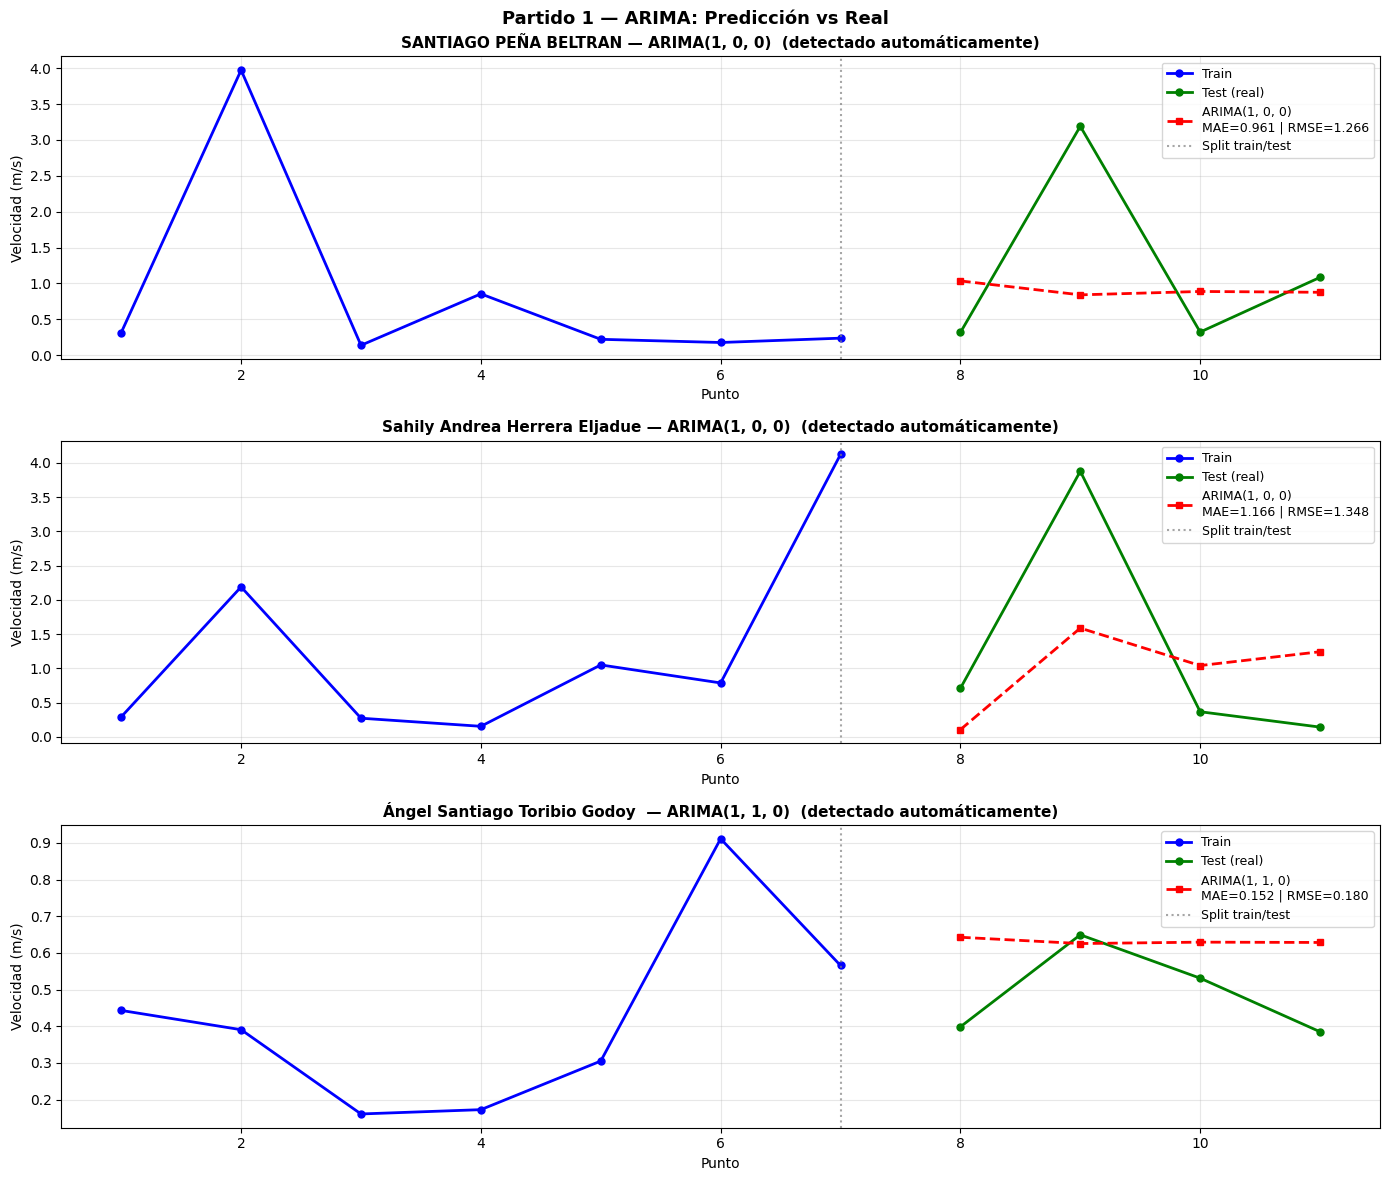

In [18]:
print('🔧 Ajustando ARIMA por jugador (orden detectado automáticamente)\n')

n_eval = len(jugadores_eval)
fig, axes = plt.subplots(n_eval, 1, figsize=(14, 4 * n_eval))
if n_eval == 1:
    axes = [axes]

for ax, jugador in zip(axes, jugadores_eval):
    datos  = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
    puntos = datos['punto_num'].values
    serie  = datos['desplazamiento_total'].values
    split  = indices_split[jugador]
    train, test = serie[:split], serie[split:]

    orden = ordenes_arima.get(jugador, (1, 1, 0))

    # ---- Protección series cortas ----
    if len(train) < 3:
        print(f'  ⚠️  {jugador}: train muy corto ({len(train)} puntos), saltando ARIMA.')
        pred_arima = np.full(len(test), train[-1] if len(train) > 0 else 0)
        ax.set_visible(False)
        continue

    if len(test) < 1:
        print(f'  ⚠️  {jugador}: sin puntos de test, saltando.')
        ax.set_visible(False)
        continue

    # Ajustar orden para no exceder tamaño de serie
    p, d, q = orden
    max_params = max(1, len(train) // 3)
    orden = (min(p, max_params), d, min(q, max_params))

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fit_arima  = ARIMA(train, order=orden).fit()
        pred_arima = np.array(fit_arima.forecast(steps=len(test)))
        mae_ar  = mean_absolute_error(test, pred_arima)
        rmse_ar = np.sqrt(mean_squared_error(test, pred_arima))
        resultados_globales[jugador].append(
            evaluar_modelo(test, pred_arima, f'ARIMA{orden}')
        )
        print(f'  ✅ {jugador} ARIMA{orden} → MAE={mae_ar:.4f} | RMSE={rmse_ar:.4f}')
    except Exception as exc:
        print(f'  ❌ Error ARIMA{orden} para {jugador}: {str(exc)[:120]}')
        pred_arima = np.full(len(test), train[-1])
        mae_ar  = mean_absolute_error(test, pred_arima)
        rmse_ar = np.sqrt(mean_squared_error(test, pred_arima))

    ax.plot(puntos[:split], train,      'b-o',  label='Train',           ms=5, lw=2)
    ax.plot(puntos[split:], test,       'g-o',  label='Test (real)',      ms=5, lw=2)
    ax.plot(puntos[split:], pred_arima, 'r--s', label=f'ARIMA{orden}\nMAE={mae_ar:.3f} | RMSE={rmse_ar:.3f}', ms=5, lw=2)
    ax.axvline(x=puntos[split - 1], color='gray', linestyle=':', alpha=0.7, label='Split train/test')
    ax.set_title(f'{jugador} — ARIMA{orden}  (detectado automáticamente)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Punto')
    ax.set_ylabel('Desplazamiento (m)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Partido {PARTIDO_NUM} — ARIMA: Predicción vs Real',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **[Análisis — ARIMA]**
> *¿Qué orden ARIMA(p,d,q) se seleccionó para cada jugador? ¿El test ADF indicó estacionariedad? ¿El modelo logra seguir la serie en el conjunto de prueba?*

## 🔮 SECCIÓN 9 — Prophet de Meta

**Prophet** captura tendencias y genera un forecast con **bandas de incertidumbre**. Aquí lo usamos para:
1. Modelar la tendencia de fatiga a lo largo del partido
2. Extrapolar el rendimiento **más allá de los puntos jugados**
3. Generar un "¿cuándo esperamos que colapse el ritmo?"

> Si Prophet no está instalado: `pip install prophet`

> ⚠️ **Nota metodológica**: Prophet requiere al menos ~20 observaciones para capturar tendencias y estacionalidad. Con < 15 puntos por jugador, se usa como modelo *demostrativo* de la metodología, no para conclusiones predictivas fuertes.

10:20:38 - cmdstanpy - INFO - Chain [1] start processing


🔮 Prophet de Meta — Partido 1



10:20:39 - cmdstanpy - INFO - Chain [1] done processing
10:20:39 - cmdstanpy - INFO - Chain [1] start processing
10:20:39 - cmdstanpy - INFO - Chain [1] done processing
10:20:39 - cmdstanpy - INFO - Chain [1] start processing
10:20:39 - cmdstanpy - INFO - Chain [1] done processing


  Prophet (Meta)                           MAE: 1.8932 m/s  |  RMSE: 2.2410 m/s
  Prophet (Meta)                           MAE: 2.3112 m/s  |  RMSE: 2.5115 m/s
  Prophet (Meta)                           MAE: 0.2343 m/s  |  RMSE: 0.2693 m/s


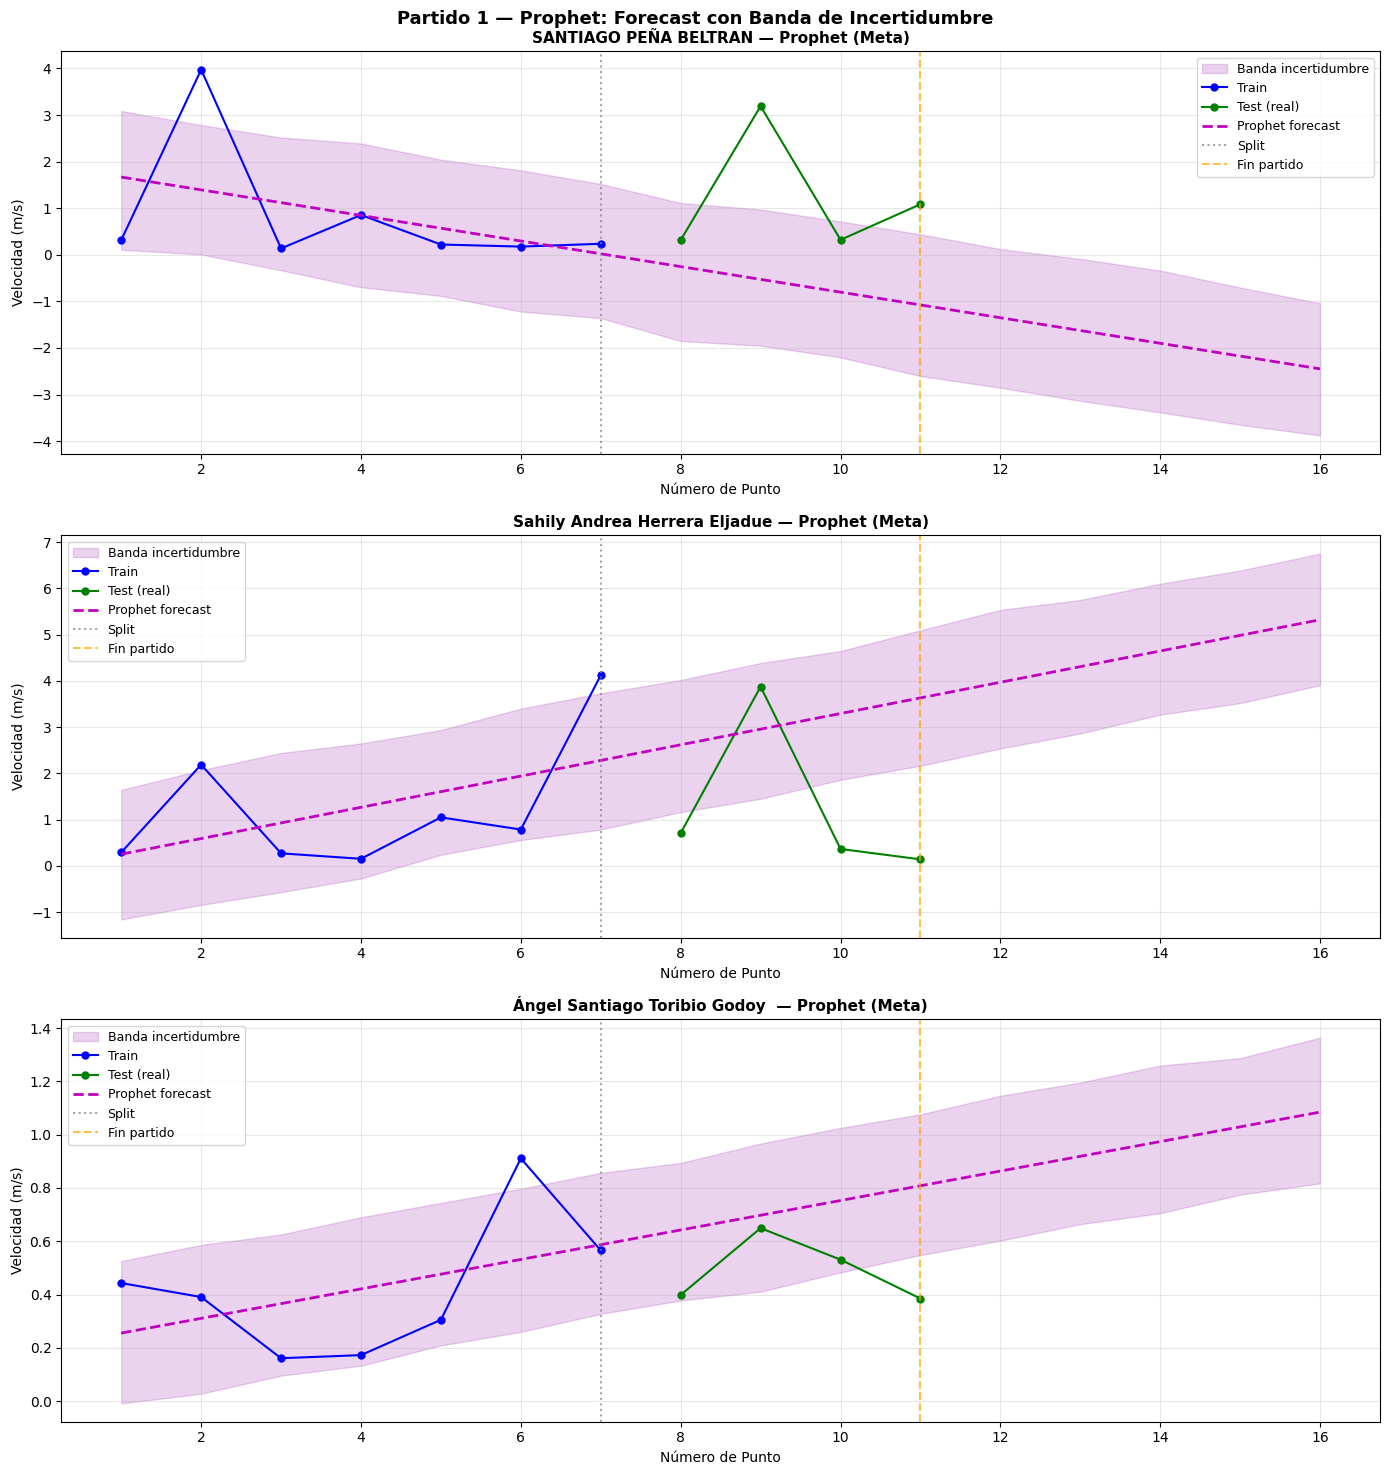

In [19]:
from datetime import datetime, timedelta

if not PROPHET_AVAILABLE:
    print('⚠️  Prophet no está instalado.')
    print('   Ejecuta en tu terminal: pip install prophet')
else:
    print(f'🔮 Prophet de Meta — Partido {PARTIDO_NUM}\n')
    FUTURE_POINTS = 5
    fecha_inicio  = datetime(2024, 1, 1)

    n_eval = len(jugadores_eval)
    fig, axes = plt.subplots(n_eval, 1, figsize=(14, 5 * n_eval))
    if n_eval == 1:
        axes = [axes]

    for ax, jugador in zip(axes, jugadores_eval):
        datos      = serie_temporal[serie_temporal['player_name'] == jugador].sort_values('punto_num')
        puntos     = datos['punto_num'].values
        serie      = datos['desplazamiento_total'].values
        split      = indices_split[jugador]
        train, test = serie[:split], serie[split:]
        max_punto   = int(puntos.max())

        fechas_all = [fecha_inicio + timedelta(days=int(p)) for p in puntos]
        df_prophet = pd.DataFrame({'ds': fechas_all, 'y': serie})
        df_train_p = df_prophet.iloc[:split]

        try:
            modelo_p = Prophet(
                yearly_seasonality=False,
                weekly_seasonality=False,
                daily_seasonality=False,
                changepoint_prior_scale=0.3
            )
            modelo_p.fit(df_train_p)

            rango_futuro  = range(1, max_punto + FUTURE_POINTS + 1)
            fechas_futuro = [fecha_inicio + timedelta(days=p) for p in rango_futuro]
            forecast      = modelo_p.predict(pd.DataFrame({'ds': fechas_futuro}))

            fechas_test   = [fecha_inicio + timedelta(days=int(p)) for p in puntos[split:]]
            pred_test_p   = forecast[forecast['ds'].isin(fechas_test)]['yhat'].values
            if len(pred_test_p) == len(test):
                resultados_globales[jugador].append(
                    evaluar_modelo(test, pred_test_p, 'Prophet (Meta)')
                )

            x_range = list(rango_futuro)
            ax.fill_between(x_range,
                            forecast['yhat_lower'].values,
                            forecast['yhat_upper'].values,
                            alpha=0.2, color='#9C27B0', label='Banda incertidumbre')
            ax.plot(puntos[:split], train,  'b-o', label='Train',        ms=5)
            ax.plot(puntos[split:], test,   'g-o', label='Test (real)',  ms=5)
            ax.plot(x_range, forecast['yhat'].values, 'm--', label='Prophet forecast', lw=2)
            ax.axvline(x=puntos[split - 1], color='gray',   linestyle=':', alpha=0.7, label='Split')
            ax.axvline(x=max_punto,          color='orange', linestyle='--', alpha=0.7, label='Fin partido')

        except Exception as exc:
            print(f'  ⚠️  Error Prophet para {jugador}: {exc}')

        ax.set_title(f'{jugador} — Prophet (Meta)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Número de Punto')
        ax.set_ylabel('Desplazamiento (m)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Partido {PARTIDO_NUM} — Prophet: Forecast con Banda de Incertidumbre',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

> **[Análisis — Prophet]**
> *¿Qué muestra la banda de incertidumbre? ¿La tendencia proyectada por Prophet es coherente con la tendencia observada en los datos? ¿Hay cambios de tendencia detectados?*

## 📋 SECCIÓN 10 — Tabla Comparativa de Modelos

In [20]:
print('=' * 70)
print(f'TABLA COMPARATIVA DE MODELOS — Partido {PARTIDO_NUM}  (MAE y RMSE en metros)')
print('=' * 70)

tabla_global = []

for jugador, lista_metricas in resultados_globales.items():
    if not lista_metricas:
        continue
    df_m = pd.DataFrame(lista_metricas).set_index('modelo')
    print(f'\n👤 {jugador}')
    print(df_m.to_string())
    print(f'   → Mejor MAE : {df_m["MAE"].idxmin()}')
    print(f'   → Mejor RMSE: {df_m["RMSE"].idxmin()}')
    for _, row in df_m.reset_index().iterrows():
        tabla_global.append({'jugador': jugador, **row.to_dict()})

print()
print('=' * 70)
print('RESUMEN GLOBAL — promedio de MAE y RMSE por modelo (todos los jugadores)')
print('=' * 70)
df_global = pd.DataFrame(tabla_global)
if not df_global.empty:
    # Agrupar variantes de ARIMA (ej. ARIMA(1,0,0), ARIMA(1,1,0)) bajo "ARIMA"
    # para una comparación justa entre familias de modelos
    df_global['modelo_familia'] = df_global['modelo'].str.replace(
        r'ARIMA\(.*?\)', 'ARIMA', regex=True
    )
    resumen = df_global.groupby('modelo_familia')[['MAE', 'RMSE']].mean().round(4).sort_values('RMSE')
    print(resumen.to_string())
    print(f'\n→ Modelo más preciso en promedio (menor RMSE): {resumen["RMSE"].idxmin()}')
    print('  (ARIMA agrupa todos los órdenes detectados automáticamente por jugador)')

print()
print('💡 MAE y RMSE en metros — menor valor = mejor predicción del desplazamiento futuro')

TABLA COMPARATIVA DE MODELOS — Partido 1  (MAE y RMSE en m/s)

👤 SANTIAGO PEÑA BELTRAN
                                  MAE    RMSE
modelo                                       
Naive (último valor conocido)  0.9920  1.5383
Exp. Smoothing (Holt)          1.9055  2.2517
ARIMA(1, 0, 0)                 0.9610  1.2656
Prophet (Meta)                 1.8932  2.2410
   → Mejor MAE : ARIMA(1, 0, 0)
   → Mejor RMSE: ARIMA(1, 0, 0)

👤 Sahily Andrea Herrera Eljadue
                                  MAE    RMSE
modelo                                       
Naive (último valor conocido)  2.8478  3.2261
Exp. Smoothing (Holt)          2.3114  2.5119
ARIMA(1, 0, 0)                 1.1663  1.3476
Prophet (Meta)                 2.3112  2.5115
   → Mejor MAE : ARIMA(1, 0, 0)
   → Mejor RMSE: ARIMA(1, 0, 0)

👤 Ángel Santiago Toribio Godoy 
                                  MAE    RMSE
modelo                                       
Naive (último valor conocido)  0.1165  0.1311
Exp. Smoothing (Holt)        

> **[Análisis — Comparación de Modelos]**
> *¿Qué modelo obtuvo el menor MAE y RMSE para cada jugador? ¿Por qué crees que ese modelo se adapta mejor a la serie temporal de este partido?*

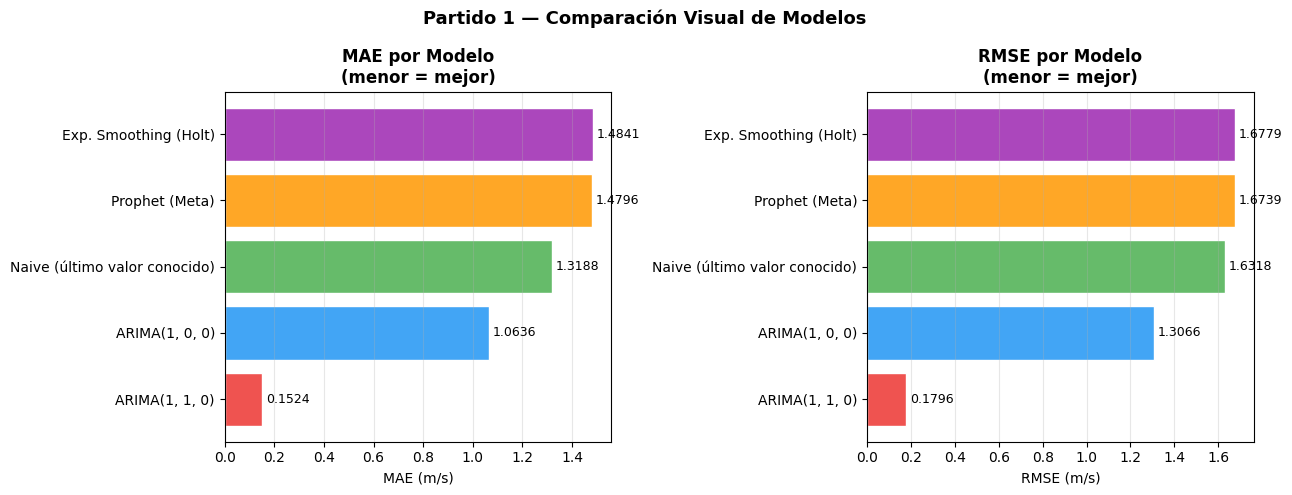

In [21]:
# ---- Bar chart visual de MAE y RMSE por modelo -------------------------
if 'resumen' in dir() and not df_global.empty and len(resumen) >= 2:
    fig_bar, ax_bar = plt.subplots(1, 2, figsize=(13, max(3, len(resumen) * 0.8 + 1)))
    _mods = resumen.index.tolist()
    _pal  = ['#EF5350', '#42A5F5', '#66BB6A', '#FFA726', '#AB47BC'][:len(_mods)]

    ax_bar[0].barh(_mods, resumen['MAE'].values,  color=_pal, edgecolor='white')
    ax_bar[0].set_title('MAE por Modelo\n(menor = mejor)', fontweight='bold')
    ax_bar[0].set_xlabel('MAE (m)')
    for _i, _v in enumerate(resumen['MAE'].values):
        ax_bar[0].text(_v + resumen['MAE'].max() * 0.01, _i, f'{_v:.4f}', va='center', fontsize=9)
    ax_bar[0].grid(True, alpha=0.3, axis='x')

    ax_bar[1].barh(_mods, resumen['RMSE'].values, color=_pal, edgecolor='white')
    ax_bar[1].set_title('RMSE por Modelo\n(menor = mejor)', fontweight='bold')
    ax_bar[1].set_xlabel('RMSE (m)')
    for _i, _v in enumerate(resumen['RMSE'].values):
        ax_bar[1].text(_v + resumen['RMSE'].max() * 0.01, _i, f'{_v:.4f}', va='center', fontsize=9)
    ax_bar[1].grid(True, alpha=0.3, axis='x')

    fig_bar.suptitle(f'Partido {PARTIDO_NUM} \u2014 Comparaci\u00f3n Visual de Modelos',
                     fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('\u26a0\ufe0f  Se necesitan al menos 2 modelos evaluados para mostrar el gr\u00e1fico.')


## 📊 SECCIÓN 11 — Comparación de Jugadores: ¿Quién se Fatiga Más Rápido?

Para responder la pregunta central necesitamos comparar la **tasa de caída de rendimiento**
entre jugadores dentro del mismo partido.

| Métrica | Descripción |
|---------|-------------|
| **Pendiente (m/punto)** | Cambio promedio de desplazamiento por cada punto jugado. Negativa = fatiga acumulada |
| **R²** | Qué tan bien se ajusta la tendencia lineal a la serie real (0–1) |

> **Nota metodológica:** Las series son cortas (~10 puntos por partido). La pendiente resume la tendencia lineal como señal descriptiva, no como prueba concluyente.

In [ ]:
from scipy import stats as _sp_stats

print(f'Comparacion de Jugadores — Partido {PARTIDO_NUM}\n')
print(f'{"Jugador":<35} {"Pendiente (m/punto)":>20} {"R2":>8} {"Interpretacion"}')
print('-' * 80)

_resumen_jug = []
for _jug in jugadores:
    _d = (serie_temporal[serie_temporal['player_name'] == _jug]
          .sort_values('punto_num')[['punto_num', 'desplazamiento_total']]
          .dropna())
    if len(_d) < 3:
        continue
    _slope, _intercept, _r, _p, _se = _sp_stats.linregress(_d['punto_num'], _d['desplazamiento_total'])
    _r2 = _r ** 2
    _interp = ('Caida fuerte' if _slope < -0.10 else
               'Caida leve' if _slope < 0 else
               'Estable/mejora')
    _resumen_jug.append({'jugador': _jug, 'pendiente': _slope, 'r2': _r2, 'interp': _interp})
    print(f'{_jug:<35} {_slope:>+20.4f} {_r2:>8.3f}  {_interp}')

if len(_resumen_jug) > 1:
    _mas_fatiga = min(_resumen_jug, key=lambda x: x['pendiente'])
    _menos_fatiga = max(_resumen_jug, key=lambda x: x['pendiente'])
    print(f'\nSe fatiga mas rapido : {_mas_fatiga["jugador"]} (pendiente {_mas_fatiga["pendiente"]:+.4f})')
    print(f'Mas estable          : {_menos_fatiga["jugador"]} (pendiente {_menos_fatiga["pendiente"]:+.4f})')

    # -- Gráfica de barras de pendiente por jugador --
    _fig11, _ax11 = plt.subplots(figsize=(max(8, len(_resumen_jug) * 2), 5))
    _nombres = [r['jugador'].split('_')[0] if '_' in r['jugador'] else r['jugador']
                for r in _resumen_jug]
    _slopes = [r['pendiente'] for r in _resumen_jug]
    _colors = ['#d9534f' if s < -0.10 else '#f0ad4e' if s < 0 else '#5cb85c' for s in _slopes]
    _ax11.bar(_nombres, _slopes, color=_colors, edgecolor='white', linewidth=0.8)
    _ax11.axhline(0, color='black', linewidth=0.8, linestyle='--')
    _ax11.set_title(f'Partido {PARTIDO_NUM} — Pendiente de Fatiga por Jugador\n'
                    '(negativo = caida de rendimiento; positivo = mejora/estable)',
                    fontweight='bold')
    _ax11.set_ylabel('Pendiente (m desplazamiento / punto)')
    _ax11.set_xlabel('Jugador')
    _ax11.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

> **[Análisis — Comparación de Jugadores]**
> *¿Qué jugador muestra la caída de rendimiento más pronunciada? ¿La pendiente negativa es consistente con lo que observaste en las gráficas anteriores? ¿Hay algún jugador que mejora o se mantiene estable?*

## 📋 SECCIÓN 13 — Tabla Resumen por Jugador

Síntesis de los resultados de todo el análisis para cada jugador del partido.

In [ ]:
# Tabla resumen: pendiente + mejor modelo + RMSE por jugador
if 'resultados_globales' in dir() and '_resumen_jug' in dir() and resultados_globales and _resumen_jug:
    _filas_res = []
    for _jug_r in _resumen_jug:
        _nombre = _jug_r['jugador']
        # Mejor modelo por RMSE
        _metricas = resultados_globales.get(_nombre, [])
        if _metricas:
            _df_m = pd.DataFrame(_metricas)
            _mejor_mod = _df_m.loc[_df_m['RMSE'].idxmin()]
            _mejor_nombre = _mejor_mod['modelo']
            _mejor_rmse   = _mejor_mod['RMSE']
        else:
            _mejor_nombre, _mejor_rmse = 'N/A', float('nan')
        _filas_res.append({
            'Jugador':       _nombre,
            'Pendiente (m/pt)': round(_jug_r['pendiente'], 4),
            'R2':            round(_jug_r['r2'], 3),
            'Interpretacion': _jug_r['interp'],
            'Mejor modelo':  _mejor_nombre,
            'RMSE (m)':      round(_mejor_rmse, 3) if not pd.isna(_mejor_rmse) else '-',
        })
    df_resumen_final = pd.DataFrame(_filas_res)
    print(f'Resumen final — Partido {PARTIDO_NUM}')
    print('=' * 80)
    print(df_resumen_final.to_string(index=False))
    print()
    print('Pendiente: cambio de desplazamiento por punto (negativo = caida de rendimiento)')
    print('RMSE en metros — menor valor indica mejor ajuste del modelo al jugador')
else:
    print('Ejecutar primero las secciones 6-11 para generar los resultados.')

## 📝 SECCIÓN 12 — Conclusiones

### Respuesta a la Pregunta Central
> **[Análisis]** *¿El rendimiento físico de un jugador sigue un patrón predecible durante el partido? ¿Se puede anticipar la fatiga con los modelos aplicados?*

### Modelo con Mejor Desempeño
> **[Análisis]** *¿Qué modelo tuvo el menor MAE/RMSE para el jugador analizado? ¿Por qué crees que fue el más adecuado para esta serie temporal?*

### Limitaciones del Estudio
> **[Análisis]** *Series cortas (~10 puntos por partido), pocos partidos disponibles...*

### Aprendizajes Personales
> **[Análisis]** *¿Qué aprendiste sobre forecasting aplicado al análisis deportivo?*